# Dubins — decoupling matrix $|\\det A|$ over output space (rebuttal figure)

Generates `detA_dubins.png` for the author response: an output-space scatter over $\\mathcal{X}_S\\setminus\\mathcal{X}_T$ colored by $|\\det A| = v$, in the `make_paper_figs` style (same $650\\times600$ canvas, view, fonts, set palette).

Adjust the **parameter** cell, then run all.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---- output directory (author_response/figs); edit if your tree differs ----
OUT = "/Users/jianqiang/Documents/Overleaf_Github_Sync/Reach-avoid-MPC/LCSS_Revsion/author_response/figs"
os.makedirs(OUT, exist_ok=True)

# ---- make_paper_figs canvas + palette + fonts (keep consistent with the paper) ----
PX = 1 / 100.0
FIGSIZE = (650 * PX, 600 * PX)  # 6.5 x 6.0 in  == make_paper_figs success-rate figs
FS_P = 30  # axis-label base font
C_SAFE_LINE, C_SAFE_FILL = "#2166ac", "#e6f2ff"
C_TGT_LINE, C_TGT_FILL = "#d6604d", "#fee0d2"


def draw_sets(ax, G1, G2, Zsafe, Ztgt, tgt_lw=2):
    ax.contourf(
        G1, G2, Zsafe, levels=[0, np.inf], colors=[C_SAFE_FILL], alpha=0.3, zorder=1
    )
    ax.contour(G1, G2, Zsafe, levels=[0], colors=[C_SAFE_LINE], linewidths=2, zorder=4)
    ax.contourf(
        G1, G2, Ztgt, levels=[-np.inf, 0], colors=[C_TGT_FILL], alpha=1.0, zorder=2
    )
    ax.contour(
        G1, G2, Ztgt, levels=[0], colors=[C_TGT_LINE], linewidths=tgt_lw, zorder=5
    )

In [2]:
# --- Dubins in OUTPUT space (y1,y2) = (x1,x2);  det A = -v  =>  |det A| = v ---
def safe_poly(y1, y2):
    return (
        1e-3
        * (-((y2) ** 2 + ((y1 + 1.7) / 0.5) ** 2 - 0.4) + 300)
        * (-(y1**4 + y2**4 - 16) * (y1**4 + y2**4 - 4))
    )


def target_poly(y1, y2):
    return y2**2 + ((y1 + 1.7) / 0.5) ** 2 - 0.4

In [3]:
# ===== parameters (edit me) =====
N = 400_000  # number of samples
SEED = 42
POS = 2.1  # position box [-POS, POS]^2
V_LO, V_HI = 0.1, 1.0  # forward-speed band  ->  |det A| = v
XLIM = (-2.1, 2.1)  # output-space view (matches the paper figure)
YLIM = (-2.1, 2.1)
S_PT = 8  # scatter marker size

In [4]:
rng = np.random.default_rng(SEED)
sx1 = rng.uniform(-POS, POS, N)
sx2 = rng.uniform(-POS, POS, N)
sv = rng.uniform(V_LO, V_HI, N)  # |det A| = v
in_RA = (safe_poly(sx1, sx2) >= 0) & (target_poly(sx1, sx2) > 0)
print(
    f"{int(in_RA.sum())} samples in X_S\\X_T, "
    f"|det A| in [{sv[in_RA].min():.2f}, {sv[in_RA].max():.2f}]"
)

154272 samples in X_S\X_T, |det A| in [0.10, 1.00]


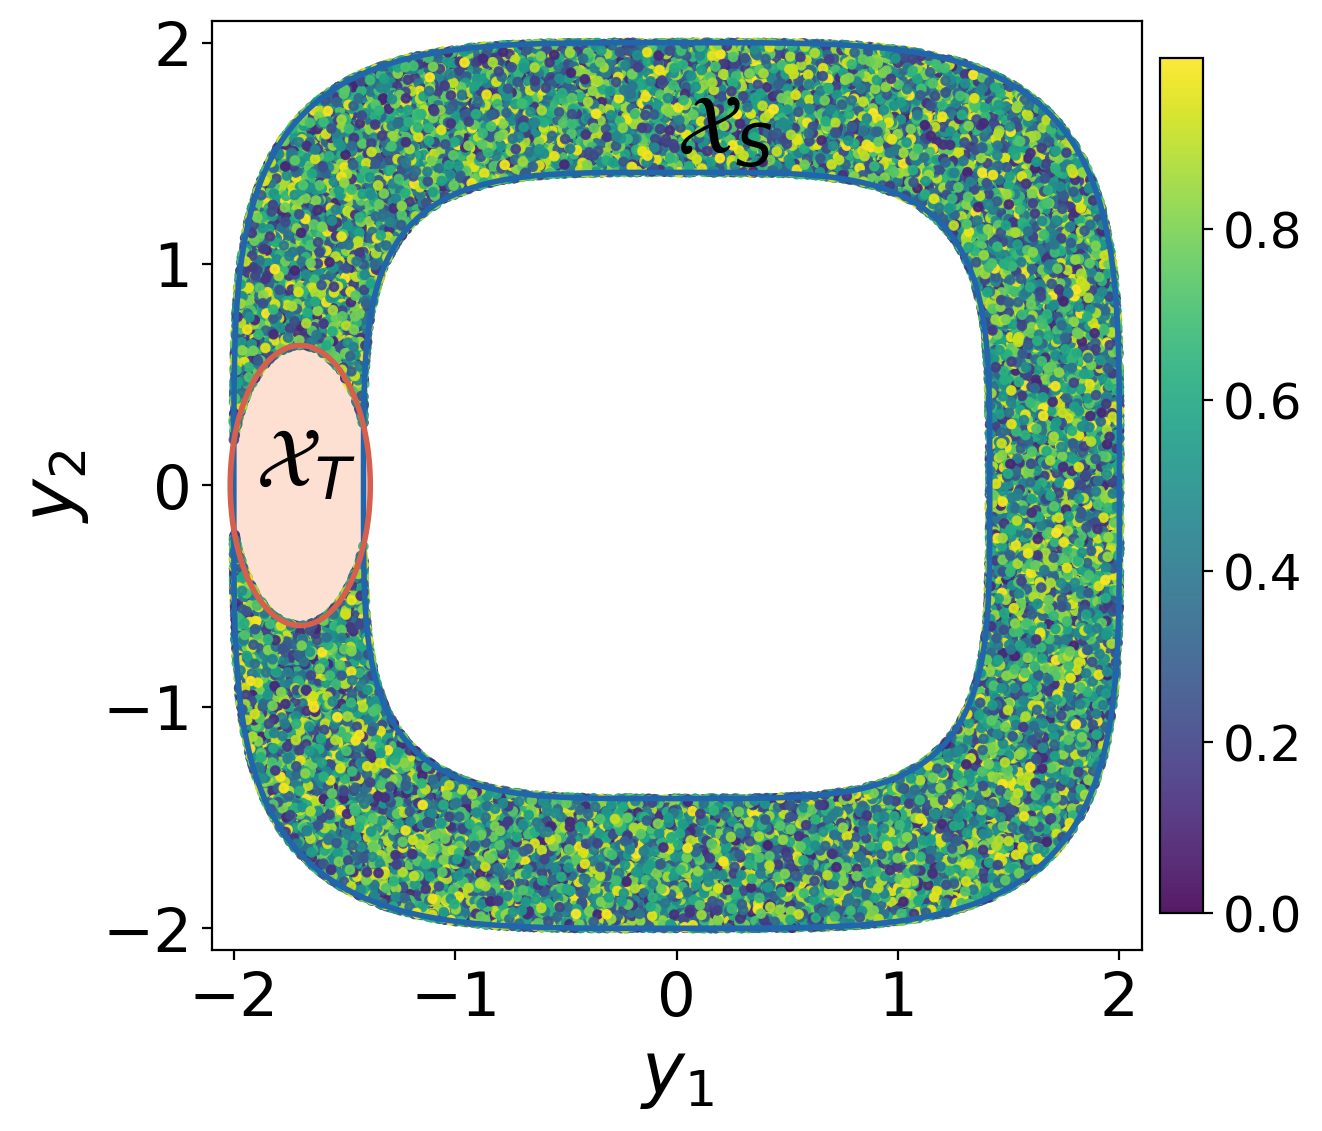

saved /Users/jianqiang/Documents/Overleaf_Github_Sync/Reach-avoid-MPC/LCSS_Revsion/author_response/figs/detA_dubins.png


In [5]:
g = np.linspace(XLIM[0], XLIM[1], 400)
G1, G2 = np.meshgrid(g, g)
fig, ax = plt.subplots(figsize=FIGSIZE, layout="constrained")
fig.set_dpi(200)
draw_sets(ax, G1, G2, safe_poly(G1, G2), target_poly(G1, G2), tgt_lw=2)
sc = ax.scatter(
    sx1[in_RA],
    sx2[in_RA],
    c=sv[in_RA],
    s=S_PT,
    cmap="viridis",
    vmin=0,
    alpha=0.9,
    zorder=3,
)
ax.text(0, 1.5, r"$\mathcal{X}_S$", fontsize=FS_P, zorder=100)
ax.text(-1.9, 0, r"$\mathcal{X}_T$", fontsize=FS_P, zorder=100)
cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
# cb.set_label(r"$|\det\mathbf{A}| = v$", fontsize=FS_P - 6)
cb.ax.tick_params(labelsize=18)
ax.set_xlabel(r"$y_1$", fontsize=FS_P - 4)
ax.set_ylabel(r"$y_2$", fontsize=FS_P - 4)
ax.xaxis.set_tick_params(labelsize=22)
ax.yaxis.set_tick_params(labelsize=22)
ax.set_xlim(*XLIM)
ax.set_ylim(*YLIM)
ax.set_aspect("equal")
fig.savefig(os.path.join(OUT, "detA_dubins.png"), dpi=200, bbox_inches="tight")
plt.show()
print("saved", os.path.join(OUT, "detA_dubins.png"))